# RAG Ablation Study - TFE Phuket

**Three ablation axes:**
1. **Embedding model** - Retrieval Recall@k for `all-MiniLM-L6-v2` vs `paraphrase-multilingual-MiniLM-L12-v2` vs `all-mpnet-base-v2`
2. **Router** - Collection routing analysis: which intents are well/poorly routed, identify gaps
3. **Refine agent** - Systematic FA / AR / IF delta between refine ON and OFF (reuses `raw_responses.csv`)

Run sections in order. Section 1 requires ChromaDB to be populated (`backend/rag/ingest.py`).

## 0. Setup & Configuration

In [1]:
import sys, os, json, time, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

# Robust ROOT detection - walk up until CLAUDE.md is found
ROOT = Path('.').resolve()
for _ in range(6):
    if (ROOT / 'CLAUDE.md').exists():
        break
    ROOT = ROOT.parent
else:
    raise RuntimeError(f'Could not find project root (CLAUDE.md) from {Path(".").resolve()}')

sys.path.insert(0, str(ROOT / 'backend'))
os.chdir(ROOT)

from dotenv import load_dotenv
load_dotenv(ROOT / 'backend' / '.env')

# --- Thesis-consistent plot style ---
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'savefig.facecolor': 'white',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 10,
})
sns.set_style('whitegrid')

MODELS = [
    'phi3:mini',
    'llama3.1:8b-instruct-q4_K_M',
    'qwen2.5:14b',
    'gpt-4o-mini',
]
MODEL_LABELS = {
    'phi3:mini':                     'phi3',
    'llama3.1:8b-instruct-q4_K_M':  'llama3.1',
    'qwen2.5:14b':                   'qwen2.5',
    'gpt-4o-mini':                   'gpt-4o-mini',
}
MODEL_COLORS = {
    'phi3:mini':                    '#4C72B0',
    'llama3.1:8b-instruct-q4_K_M': '#DD8452',
    'qwen2.5:14b':                  '#55A868',
    'gpt-4o-mini':                  '#C44E52',
}

FIGSIZE = (12, 5)

EMBED_MODELS = [
    'all-MiniLM-L6-v2',
    'paraphrase-multilingual-MiniLM-L12-v2',
    'all-mpnet-base-v2',
]
EMBED_LABELS = {
    'all-MiniLM-L6-v2':                     'MiniLM-L6',
    'paraphrase-multilingual-MiniLM-L12-v2': 'Multilingual\nMiniLM-L12\n(selected)',
    'all-mpnet-base-v2':                     'MPNet-base',
}
EMBED_COLORS = ['#4C72B0', '#DD8452', '#55A868']

with open(ROOT / 'notebooks' / 'eval' / 'benchmark.json') as f:
    BENCHMARK = json.load(f)

RESULTS_DIR = ROOT / 'notebooks' / 'eval' / 'results_ablation'
RESULTS_DIR.mkdir(exist_ok=True)

print(f'ROOT: {ROOT}')
print(f'Benchmark: {len(BENCHMARK)} questions')
print(f'Results dir: {RESULTS_DIR}')

ROOT: /Users/mathieuzilli/Desktop/Thai/TFE_Phuket
Benchmark: 60 questions
Results dir: /Users/mathieuzilli/Desktop/Thai/TFE_Phuket/notebooks/eval/results_ablation


## 1. Embedding Model Ablation - Retrieval Recall@k

For factual benchmark questions, the ground-truth chunk is identified via `source_filter` (corridor_id, year, month).  
We load all chunks from ChromaDB `traffic_monthly` collection, then rank them with 3 embedding models and measure whether the relevant chunk appears in top-k results.

**Recall@k = fraction of questions where at least one ground-truth chunk appears in top-k.**

In [2]:
import chromadb
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity as cos_sim

CHROMA_PATH = str(ROOT / 'backend' / 'rag' / '..' / 'chroma_db')
client = chromadb.PersistentClient(path=CHROMA_PATH)

# Load all chunks from traffic_monthly (the collection used for factual FA questions)
coll = client.get_collection('traffic_monthly')
all_chunks = coll.get(include=['documents', 'metadatas'])
chunk_texts = all_chunks['documents']
chunk_metas = all_chunks['metadatas']

print(f'Loaded {len(chunk_texts)} chunks from traffic_monthly')
print(f'Sample metadata: {chunk_metas[0]}')

Loaded 96 chunks from traffic_monthly
Sample metadata: {'corridor_name': 'Airport Road (Route 402)', 'month': 1, 'source': 'traffic_monthly', 'year': 2023, 'corridor_id': 0, 'season': 'high_peak'}


In [3]:
# Factual benchmark questions only (those with source_filter)
factual_qs = [q for q in BENCHMARK if q.get('source_filter') and not q['out_of_scope']]
print(f'Factual questions for ablation: {len(factual_qs)}')

def find_relevant_chunk_idxs(q: dict) -> list[int]:
    """Return indices of chunks matching the question's source_filter."""
    sf = q['source_filter']
    relevant = []
    for i, meta in enumerate(chunk_metas):
        match = True
        if 'corr_id' in sf and meta.get('corridor_id') != sf['corr_id']:
            match = False
        if 'year' in sf and meta.get('year') != sf['year']:
            match = False
        if 'month' in sf and meta.get('month') != sf['month']:
            match = False
        if match:
            relevant.append(i)
    return relevant

# Pre-compute relevant chunk indices per question
q_relevant = {q['id']: find_relevant_chunk_idxs(q) for q in factual_qs}
coverage = {qid: len(idxs) for qid, idxs in q_relevant.items()}
print(f'Mean relevant chunks per question: {np.mean(list(coverage.values())):.1f}')
print(f'Questions with 0 relevant chunks: {sum(1 for v in coverage.values() if v == 0)}')

Factual questions for ablation: 12
Mean relevant chunks per question: 1.0
Questions with 0 relevant chunks: 0


In [4]:
# Compute Recall@k for each embedding model
K_VALUES = [1, 3, 5, 10]
recall_results = {}  # model -> {k: recall}

for embed_model_name in EMBED_MODELS:
    print(f'\nEncoding with {embed_model_name}...')
    embed_model = SentenceTransformer(embed_model_name)
    
    # Encode all chunks once
    chunk_embs = embed_model.encode(chunk_texts, show_progress_bar=True, batch_size=64)
    
    # Encode queries
    queries = [q['question_en'] for q in factual_qs]
    query_embs = embed_model.encode(queries, show_progress_bar=True)
    
    recall_at_k = {k: [] for k in K_VALUES}
    
    for i, q in enumerate(factual_qs):
        relevant_idxs = set(q_relevant[q['id']])
        if not relevant_idxs:
            continue
        
        # Rank all chunks by cosine similarity
        sims = cos_sim([query_embs[i]], chunk_embs)[0]
        ranked = np.argsort(-sims)  # descending
        
        for k in K_VALUES:
            top_k_idxs = set(ranked[:k])
            hit = len(top_k_idxs & relevant_idxs) > 0
            recall_at_k[k].append(float(hit))
    
    recall_results[embed_model_name] = {k: np.mean(v) for k, v in recall_at_k.items()}
    print(f'  Recall@1={recall_results[embed_model_name][1]:.3f}, '
          f'Recall@5={recall_results[embed_model_name][5]:.3f}, '
          f'Recall@10={recall_results[embed_model_name][10]:.3f}')

recall_df = pd.DataFrame(recall_results).T
recall_df.index.name = 'Model'
recall_df.columns = [f'Recall@{k}' for k in K_VALUES]
print('\n=== Retrieval Recall@k ===')
print(recall_df.to_string())


Encoding with all-MiniLM-L6-v2...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

  Recall@1=0.000, Recall@5=0.333, Recall@10=0.583

Encoding with paraphrase-multilingual-MiniLM-L12-v2...


...

  Recall@1=0.000, Recall@5=0.583, Recall@10=0.917

Encoding with all-mpnet-base-v2...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

  Recall@1=0.000, Recall@5=0.167, Recall@10=0.333

=== Retrieval Recall@k ===
                                       Recall@1  Recall@3  Recall@5  Recall@10
Model                                                                         
all-MiniLM-L6-v2                            0.0  0.166667  0.333333   0.583333
paraphrase-multilingual-MiniLM-L12-v2       0.0  0.250000  0.583333   0.916667
all-mpnet-base-v2                           0.0  0.083333  0.166667   0.333333


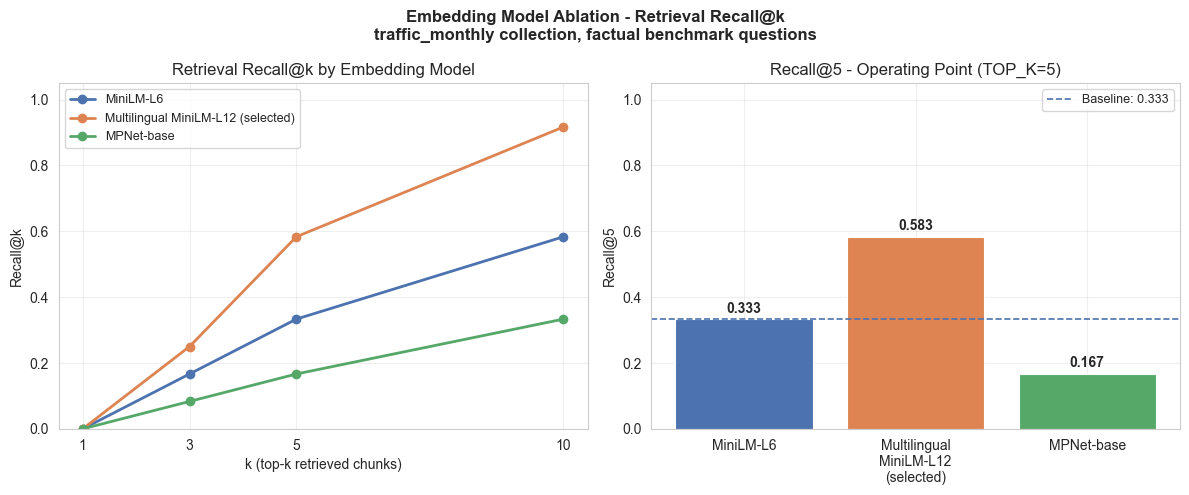

Saved embedding_recall.png and embedding_recall.csv


In [20]:
fig, axes = plt.subplots(1, 2, figsize=FIGSIZE)
fig.suptitle('Embedding Model Ablation - Retrieval Recall@k\ntraffic_monthly collection, factual benchmark questions',
             fontsize=12, fontweight='bold')

# Recall@k line plot
for i, (model_name, row) in enumerate(recall_df.iterrows()):
    label = EMBED_LABELS.get(model_name, model_name)
    axes[0].plot(K_VALUES, row.values, 'o-', linewidth=2,
                 color=EMBED_COLORS[i], label=label.replace('\n', ' '))

axes[0].set_xlabel('k (top-k retrieved chunks)')
axes[0].set_ylabel('Recall@k')
axes[0].set_title('Retrieval Recall@k by Embedding Model')
axes[0].set_xticks(K_VALUES)
axes[0].set_ylim(0, 1.05)
axes[0].legend(fontsize=9)

# Bar chart at k=5 (operating point used by retriever)
r5_values = [recall_results[m][5] for m in EMBED_MODELS]
short_labels = [EMBED_LABELS[m].replace('\n', '\n') for m in EMBED_MODELS]
bars = axes[1].bar(short_labels, r5_values, color=EMBED_COLORS,
                   edgecolor='white', linewidth=0.8)
axes[1].set_ylim(0, 1.05)
axes[1].set_ylabel('Recall@5')
axes[1].set_title('Recall@5 - Operating Point (TOP_K=5)')
axes[1].axhline(r5_values[0], color='#4C72B0', linestyle='--', linewidth=1.2,
                label=f'Baseline: {r5_values[0]:.3f}')
axes[1].legend(fontsize=9)
for bar, v in zip(bars, r5_values):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 0.02, f'{v:.3f}',
                 ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'embedding_recall.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

recall_df.to_csv(RESULTS_DIR / 'embedding_recall.csv')
print('Saved embedding_recall.png and embedding_recall.csv')

## 2. Router Ablation - Collection Routing Analysis

The keyword-based router in `retriever.py` selects which ChromaDB collections to query.  
We analyze: which collections are selected per intent class, and which questions route to irrelevant collections.

**Routing coverage:** fraction of questions where the ground-truth collection (e.g., `traffic_monthly` for factual questions) is selected.

In [6]:
from rag.retriever import _select_collections

# Analyze routing for all benchmark questions
routing_rows = []
for q in BENCHMARK:
    selected = _select_collections(q['question_en'])
    routing_rows.append({
        'id': q['id'],
        'intent': q['intent'],
        'out_of_scope': q['out_of_scope'],
        'selected_collections': ','.join(sorted(selected)),
        'n_collections': len(selected),
        'has_traffic_monthly': 'traffic_monthly' in selected,
        'has_events': 'events' in selected,
        'has_flights': 'flights' in selected,
        'has_weather': 'weather' in selected,
        'has_social': 'social_trends' in selected,
        'has_transport': 'transport' in selected,
        'has_poi': 'poi' in selected,
    })

routing_df = pd.DataFrame(routing_rows)

print('=== Collection selection frequency per intent ===')
coll_cols = [c for c in routing_df.columns if c.startswith('has_')]
freq = routing_df.groupby('intent')[coll_cols].mean()
freq.columns = [c.replace('has_', '') for c in freq.columns]
print(freq.round(2).to_string())

print('\n=== Mean collections selected per intent ===')
print(routing_df.groupby('intent')['n_collections'].mean().to_string())

=== Collection selection frequency per intent ===
              traffic_monthly  events  flights  weather  social  transport   poi
intent                                                                          
decision                 0.80    0.20     0.50     0.10     0.0       0.20  0.20
explain                  1.00    0.20     0.70     0.20     0.1       0.00  0.00
forecast                 1.00    0.10     0.40     0.20     0.1       0.00  0.00
nowcast                  1.00    0.00     0.42     0.08     0.0       0.17  0.00
out_of_scope             0.75    0.25     0.50     0.00     0.0       0.12  0.25
whatif                   0.90    0.20     0.30     0.20     0.1       0.00  0.10

=== Mean collections selected per intent ===
intent
decision        2.400000
explain         2.800000
forecast        2.300000
nowcast         1.666667
out_of_scope    2.250000
whatif          2.600000


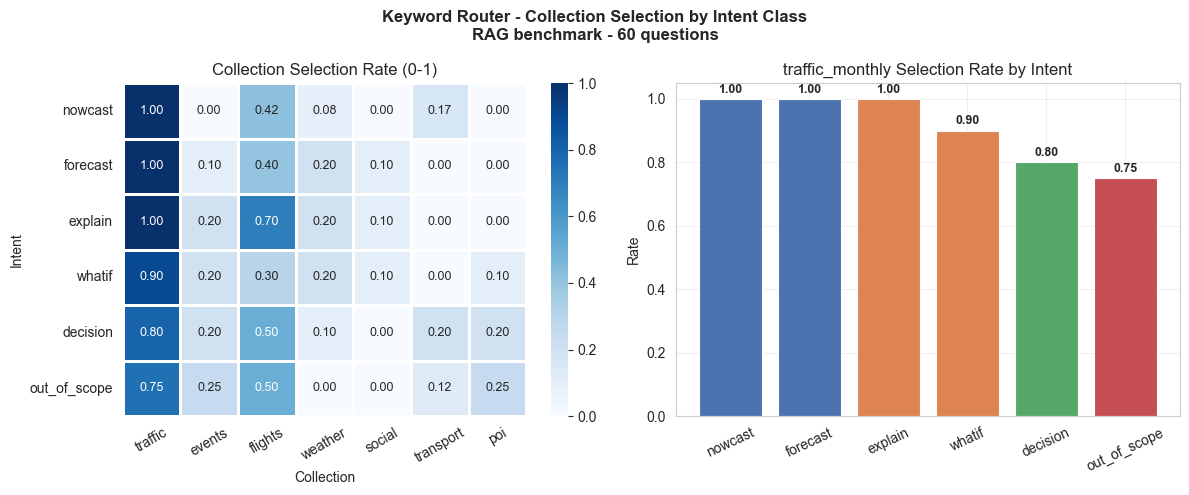

In [7]:
fig, axes = plt.subplots(1, 2, figsize=FIGSIZE)
fig.suptitle('Keyword Router - Collection Selection by Intent Class\nRAG benchmark - 60 questions',
             fontsize=12, fontweight='bold')

# Heatmap: intent × collection
coll_short = ['traffic', 'events', 'flights', 'weather', 'social', 'transport', 'poi']
intent_order = ['nowcast', 'forecast', 'explain', 'whatif', 'decision', 'out_of_scope']

heatmap_data = routing_df.groupby('intent')[
    ['has_traffic_monthly', 'has_events', 'has_flights', 'has_weather', 'has_social', 'has_transport', 'has_poi']
].mean().reindex(intent_order)
heatmap_data.columns = coll_short

sns.heatmap(heatmap_data, annot=True, fmt='.2f', cmap='Blues', vmin=0, vmax=1,
            ax=axes[0], linewidths=0.8, linecolor='white',
            annot_kws={'size': 9})
axes[0].set_title('Collection Selection Rate (0-1)')
axes[0].set_xlabel('Collection')
axes[0].set_ylabel('Intent')
axes[0].tick_params(axis='x', rotation=30)

# Bar: routing coverage (traffic_monthly selected) per intent
all_coverage = routing_df.groupby('intent')['has_traffic_monthly'].mean().reindex(intent_order)

intent_colors = ['#4C72B0', '#4C72B0', '#DD8452', '#DD8452', '#55A868', '#C44E52']
bars = axes[1].bar(intent_order, all_coverage.values,
                   color=intent_colors, edgecolor='white', linewidth=0.8)
axes[1].set_ylim(0, 1.05)
axes[1].set_ylabel('Rate')
axes[1].set_title('traffic_monthly Selection Rate by Intent')
axes[1].tick_params(axis='x', rotation=25)
for bar, v in zip(bars, all_coverage.values):
    if not np.isnan(v):
        axes[1].text(bar.get_x() + bar.get_width()/2, v + 0.02, f'{v:.2f}',
                     ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'router_analysis.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

In [8]:
# Identify routing failures: questions where expected collection is NOT selected
print('=== Routing failures - factual questions missing traffic_monthly ===')
failures = routing_df[
    routing_df['intent'].isin(['nowcast', 'forecast']) &
    ~routing_df['has_traffic_monthly']
]
if len(failures) == 0:
    print('None - all factual questions route to traffic_monthly.')
else:
    for _, row in failures.iterrows():
        q_text = next(q['question_en'] for q in BENCHMARK if q['id'] == row['id'])
        print(f"  {row['id']} [{row['intent']}]: {q_text[:80]}")
        print(f"    -> selected: {row['selected_collections']}")

print(f'\nTotal routing failures: {len(failures)} / {len(routing_df[routing_df["intent"].isin(["nowcast", "forecast"])])}')

# Analyze keyword coverage: which words trigger routing?
trigger_counts = {}
from rag.retriever import ROUTING_TABLE
for q in BENCHMARK:
    q_lower = q['question_en'].lower()
    matched = [kw for kw in ROUTING_TABLE if kw in q_lower]
    trigger_counts[q['id']] = matched

no_trigger = [qid for qid, kws in trigger_counts.items() if not kws]
print(f'\nQuestions with no routing keyword (use DEFAULT_COLLECTIONS): {len(no_trigger)}')
for qid in no_trigger:
    q_text = next(q['question_en'] for q in BENCHMARK if q['id'] == qid)
    print(f'  {qid}: {q_text[:80]}')

=== Routing failures - factual questions missing traffic_monthly ===
None - all factual questions route to traffic_monthly.

Total routing failures: 0 / 22

Questions with no routing keyword (use DEFAULT_COLLECTIONS): 7
  FC_005: Which corridor is the most congested overall in 2024?
  EX_006: Why is Bypass Road generally less congested than Patong Hill?
  EX_010: Why does Phuket Town to Rawai have the highest PTI among all corridors?
  DE_002: Should I take Bypass Road or Patong Hill on a Friday PM peak?
  DE_006: For a tourist arriving at HKT at 8am, which road should they avoid?
  OOS_005: How many cars are registered in Phuket province?
  OOS_007: What is the current petrol price in Phuket?


## 3. Refine Agent — Systematic Evaluation

Reuses `results/raw_responses.csv` collected in `rag_evaluation.ipynb`.  
Compares refine ON vs OFF across FA, AR, and IF per model - going beyond the BERTScore delta.

In [2]:
PREV_RESULTS = ROOT / 'notebooks' / 'eval' / 'results'

raw_df = pd.read_csv(PREV_RESULTS / 'raw_responses.csv')
print(f'Loaded {len(raw_df)} rows from raw_responses.csv')

REFUSAL_PHRASES = [
    "don't have", "do not have", "no information", "not available",
    "cannot find", "no data", "outside", "not in", "unable to", "no relevant",
    "i don't know", "beyond the scope", "not covered"
]

def check_factual(row) -> float | None:
    if pd.isna(row.get('expected_value')):
        return None
    if not isinstance(row['answer'], str):
        return 0.0
    expected = float(row['expected_value'])
    tolerance = abs(expected) * 0.05 + 0.01
    nums = re.findall(r'\b(\d[\d,]*\.?\d*)\b', row['answer'].replace(',', ''))
    for n_str in nums:
        try:
            if abs(float(n_str) - expected) <= tolerance:
                return 1.0
        except ValueError:
            continue
    return 0.0

raw_df['fa_correct'] = raw_df.apply(check_factual, axis=1)

# FA: refine ON vs OFF
fa_base = raw_df[~raw_df['refine'] & raw_df['fa_correct'].notna()].groupby('model')['fa_correct'].mean()
fa_refine = raw_df[raw_df['refine'] & raw_df['fa_correct'].notna()].groupby('model')['fa_correct'].mean()

print('=== Factual Accuracy: refine OFF vs refine ON ===')
fa_comp = pd.DataFrame({'Without refine': fa_base, 'With refine': fa_refine}).reindex(MODELS)
fa_comp['Delta'] = fa_comp['With refine'] - fa_comp['Without refine']
print(fa_comp.round(3).to_string())

Loaded 480 rows from raw_responses.csv
=== Factual Accuracy: refine OFF vs refine ON ===
                             Without refine  With refine  Delta
model                                                          
phi3:mini                             0.833        0.833  0.000
llama3.1:8b-instruct-q4_K_M           0.917        0.917  0.000
qwen2.5:14b                           0.917        1.000  0.083
gpt-4o-mini                           0.917        0.917  0.000


In [3]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

embed_model = SentenceTransformer('all-MiniLM-L6-v2')

def compute_ar(df_sub):
    """Compute AR for a subset dataframe."""
    df_sub = df_sub[df_sub['answer'].notna()].copy()
    q_embs = embed_model.encode(df_sub['question'].tolist(), show_progress_bar=False)
    a_embs = embed_model.encode(df_sub['answer'].tolist(), show_progress_bar=False)
    return np.array([cosine_similarity([q], [a])[0][0] for q, a in zip(q_embs, a_embs)])

# AR: refine ON vs OFF
ar_base_rows, ar_refine_rows = [], []
for model in MODELS:
    base = raw_df[(raw_df['model'] == model) & ~raw_df['refine']]
    ref  = raw_df[(raw_df['model'] == model) & raw_df['refine']]
    ar_base_rows.append({'model': model, 'ar': compute_ar(base).mean()})
    ar_refine_rows.append({'model': model, 'ar': compute_ar(ref).mean()})

ar_base   = pd.DataFrame(ar_base_rows).set_index('model')['ar']
ar_refine = pd.DataFrame(ar_refine_rows).set_index('model')['ar']

print('=== Answer Relevancy: refine OFF vs refine ON ===')
ar_comp = pd.DataFrame({'Without refine': ar_base, 'With refine': ar_refine})
ar_comp['Delta'] = ar_comp['With refine'] - ar_comp['Without refine']
print(ar_comp.round(3).to_string())

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

=== Answer Relevancy: refine OFF vs refine ON ===
                             Without refine  With refine  Delta
model                                                          
phi3:mini                             0.716        0.640 -0.075
llama3.1:8b-instruct-q4_K_M           0.777        0.744 -0.032
qwen2.5:14b                           0.782        0.771 -0.011
gpt-4o-mini                           0.836        0.793 -0.043


In [4]:
# IF: load from intent_fidelity.csv (refine=False already)
# Re-run classify on refine=True answers if not already done
if_cache = RESULTS_DIR / 'intent_fidelity_refine.csv'

if if_cache.exists():
    df_if_refine = pd.read_csv(if_cache)
    print(f'Loaded IF refine from cache: {len(df_if_refine)} rows')
else:
    from rag.prompt_builder import call_llm

    JUDGE_SYSTEM = """Classify the following answer into one of these categories:
- nowcast: describes current or recent traffic/weather conditions
- forecast: predicts future conditions or seasonal trends
- explain: explains causes or factors behind traffic patterns
- whatif: analyzes a hypothetical scenario
- decision: gives a recommendation or actionable advice
- out_of_scope: admits not having the information or refuses to answer

Reply with ONLY the category name, nothing else."""

    def classify_answer(answer: str) -> str:
        if not isinstance(answer, str) or answer.startswith('['):
            return 'error'
        result = call_llm(f"Answer to classify:\n{answer[:500]}",
                           model='gpt-4o-mini', system=JUDGE_SYSTEM)
        result = result.strip().lower()
        valid = ['nowcast','forecast','explain','whatif','decision','out_of_scope']
        return result if result in valid else 'unknown'

    df_refine_answers = raw_df[raw_df['refine'] & raw_df['answer'].notna()].copy()
    print(f'Classifying {len(df_refine_answers)} refine=True answers...')
    df_refine_answers['predicted_intent'] = df_refine_answers['answer'].apply(classify_answer)
    df_refine_answers.to_csv(if_cache, index=False)
    df_if_refine = df_refine_answers
    print('Done.')

# Load base IF from existing notebook results
df_if_base = pd.read_csv(PREV_RESULTS / 'intent_fidelity.csv')

if_base   = df_if_base.groupby('model').apply(lambda g: (g['intent'] == g['predicted_intent']).mean())
if_refine = df_if_refine.groupby('model').apply(lambda g: (g['intent'] == g['predicted_intent']).mean())

print('\n=== Intent Fidelity: refine OFF vs refine ON ===')
if_comp = pd.DataFrame({'Without refine': if_base, 'With refine': if_refine}).reindex(MODELS)
if_comp['Delta'] = if_comp['With refine'] - if_comp['Without refine']
print(if_comp.round(3).to_string())

Loaded IF refine from cache: 240 rows

=== Intent Fidelity: refine OFF vs refine ON ===
                             Without refine  With refine  Delta
model                                                          
phi3:mini                             0.567        0.550 -0.017
llama3.1:8b-instruct-q4_K_M           0.483        0.517  0.033
qwen2.5:14b                           0.650        0.700  0.050
gpt-4o-mini                           0.567        0.517 -0.050


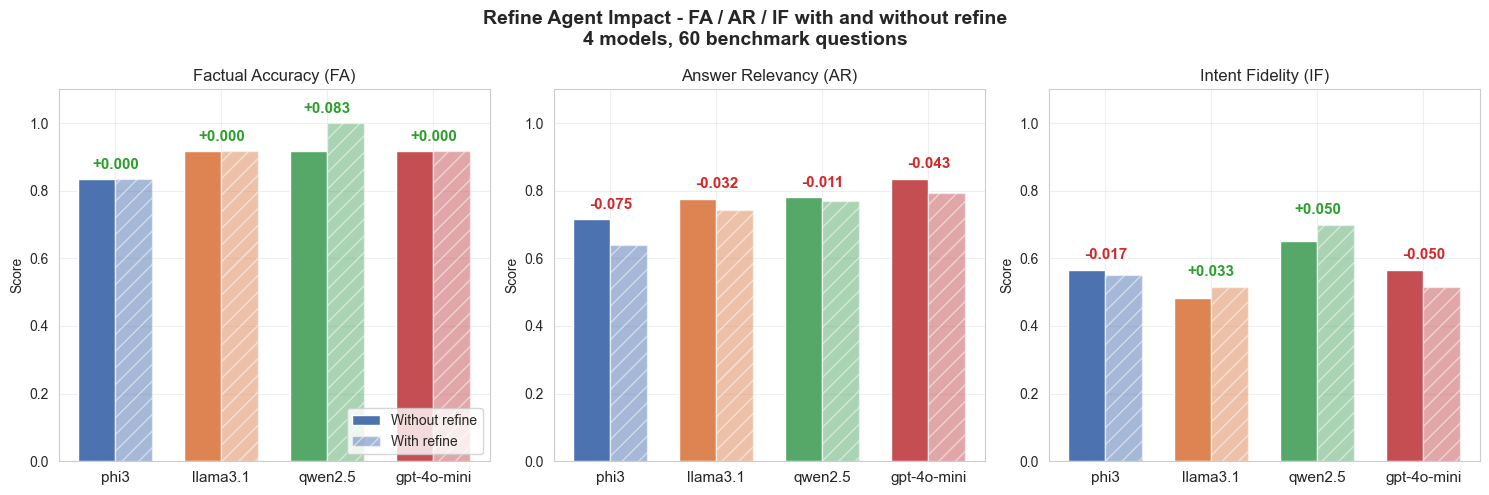

In [5]:
labels = [MODEL_LABELS[m] for m in MODELS]
colors = [MODEL_COLORS[m] for m in MODELS]
x = np.arange(len(MODELS))
width = 0.35

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Refine Agent Impact - FA / AR / IF with and without refine\n4 models, 60 benchmark questions',
             fontsize=14, fontweight='bold')

comparisons = [
    ('Factual Accuracy (FA)', fa_comp, axes[0]),
    ('Answer Relevancy (AR)', ar_comp, axes[1]),
    ('Intent Fidelity (IF)', if_comp, axes[2]),
]

for title, comp_df, ax in comparisons:
    base_vals   = comp_df.reindex(MODELS)['Without refine'].fillna(0).values
    refine_vals = comp_df.reindex(MODELS)['With refine'].fillna(0).values

    ax.bar(x - width/2, base_vals,   width, label='Without refine',
           color=colors, alpha=1.0, edgecolor='white')
    ax.bar(x + width/2, refine_vals, width, label='With refine',
           color=colors, alpha=0.5, edgecolor='white', hatch='//')

    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=11)
    ax.set_ylim(0, 1.1)
    ax.set_ylabel('Score')
    ax.set_title(title)

    # Delta annotations
    for i, (bv, rv) in enumerate(zip(base_vals, refine_vals)):
        delta = rv - bv
        color_d = '#2ca02c' if delta >= 0 else '#d62728'
        ax.text(i, max(bv, rv) + 0.03, f'{delta:+.3f}',
                ha='center', fontsize=11, color=color_d, fontweight='bold')

axes[0].legend(fontsize=10, loc='lower right')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'refine_impact.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

Batches:   0%|          | 0/15 [00:00<?, ?it/s]

Batches:   0%|          | 0/15 [00:00<?, ?it/s]

=== AR by intent: refine ON vs OFF ===
              Without refine  With refine  Delta
intent                                          
decision               0.753        0.703 -0.049
explain                0.777        0.746 -0.031
forecast               0.753        0.714 -0.039
nowcast                0.825        0.750 -0.074
out_of_scope           0.792        0.786 -0.006
whatif                 0.760        0.730 -0.030


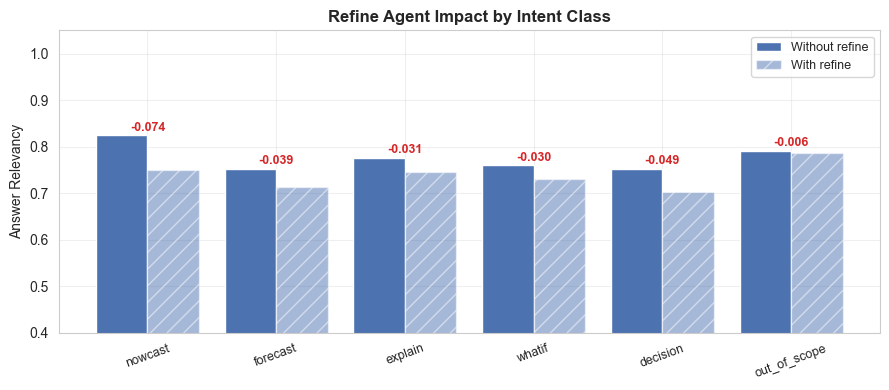

In [6]:
# Breakdown: refine impact by intent class
from sklearn.metrics.pairwise import cosine_similarity

df_base_full = raw_df[~raw_df['refine'] & raw_df['answer'].notna()].copy()
df_base_full['fa_correct'] = df_base_full.apply(check_factual, axis=1)

df_ref_full = raw_df[raw_df['refine'] & raw_df['answer'].notna()].copy()
df_ref_full['fa_correct'] = df_ref_full.apply(check_factual, axis=1)

# AR by intent
all_answers = pd.concat([df_base_full, df_ref_full])[['question', 'answer', 'intent', 'refine']].dropna()
q_embs = embed_model.encode(all_answers['question'].tolist(), show_progress_bar=True)
a_embs = embed_model.encode(all_answers['answer'].tolist(),  show_progress_bar=True)
all_answers['ar'] = [cosine_similarity([q],[a])[0][0] for q,a in zip(q_embs, a_embs)]

ar_intent = all_answers.groupby(['intent', 'refine'])['ar'].mean().unstack()
ar_intent.columns = ['Without refine', 'With refine']
ar_intent['Delta'] = ar_intent['With refine'] - ar_intent['Without refine']
print('=== AR by intent: refine ON vs OFF ===')
print(ar_intent.round(3).to_string())

fig, ax = plt.subplots(figsize=(9, 4))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

intent_order = ['nowcast', 'forecast', 'explain', 'whatif', 'decision', 'out_of_scope']
ar_intent_ordered = ar_intent.reindex(intent_order)

x2 = np.arange(len(intent_order))
ax.bar(x2 - 0.2, ar_intent_ordered['Without refine'].values, 0.4,
       label='Without refine', color='#4C72B0', edgecolor='white')
ax.bar(x2 + 0.2, ar_intent_ordered['With refine'].values, 0.4,
       label='With refine', color='#4C72B0', alpha=0.5, edgecolor='white', hatch='//')

for i, delta in enumerate(ar_intent_ordered['Delta'].values):
    col = '#2ca02c' if delta >= 0 else '#d62728'
    ax.text(i, max(ar_intent_ordered['Without refine'].iloc[i],
                   ar_intent_ordered['With refine'].iloc[i]) + 0.01,
            f'{delta:+.3f}', ha='center', fontsize=9, color=col, fontweight='bold')

ax.set_xticks(x2)
ax.set_xticklabels(intent_order, rotation=20, fontsize=9)
ax.set_ylim(0.4, 1.05)
ax.set_ylabel('Answer Relevancy')
ax.set_title('Refine Agent Impact by Intent Class', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'refine_by_intent.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

## 4. Summary Dashboard

Consolidated view: embedding ablation winner + routing gaps + refine agent recommendation.

In [7]:
# Embedding ablation summary
embed_summary = recall_df[['Recall@1', 'Recall@5', 'Recall@10']].copy()
embed_summary.index = [EMBED_LABELS[m].replace('\n', ' ') for m in embed_summary.index]

# Routing summary
routing_summary = routing_df.groupby('intent')['n_collections'].agg(['mean', 'min', 'max'])

# Refine summary (mean delta across models)
fa_delta_mean = fa_comp['Delta'].mean()
ar_delta_mean = ar_comp['Delta'].mean()
if_delta_mean = if_comp['Delta'].mean()

print('=== ABLATION STUDY SUMMARY ===')
print('\n1. Embedding ablation (Recall@5):')
for i, m in enumerate(EMBED_MODELS):
    label = EMBED_LABELS[m].replace('\n', ' ')
    r5 = recall_results[m][5]
    marker = ' <- CURRENT' if i == 0 else ''
    print(f'   {label}: {r5:.3f}{marker}')

print('\n2. Routing coverage (factual questions → traffic_monthly):')
for intent in ['nowcast', 'forecast']:
    coverage_val = routing_df[routing_df['intent'] == intent]['has_traffic_monthly'].mean()
    print(f'   {intent}: {coverage_val:.1%}')

print('\n3. Refine agent impact (mean delta across 4 models):')
print(f'   FA delta:  {fa_delta_mean:+.4f}')
print(f'   AR delta:  {ar_delta_mean:+.4f}')
print(f'   IF delta:  {if_delta_mean:+.4f}')
print(f'   Overall:   {np.mean([fa_delta_mean, ar_delta_mean, if_delta_mean]):+.4f}')

NameError: name 'recall_df' is not defined

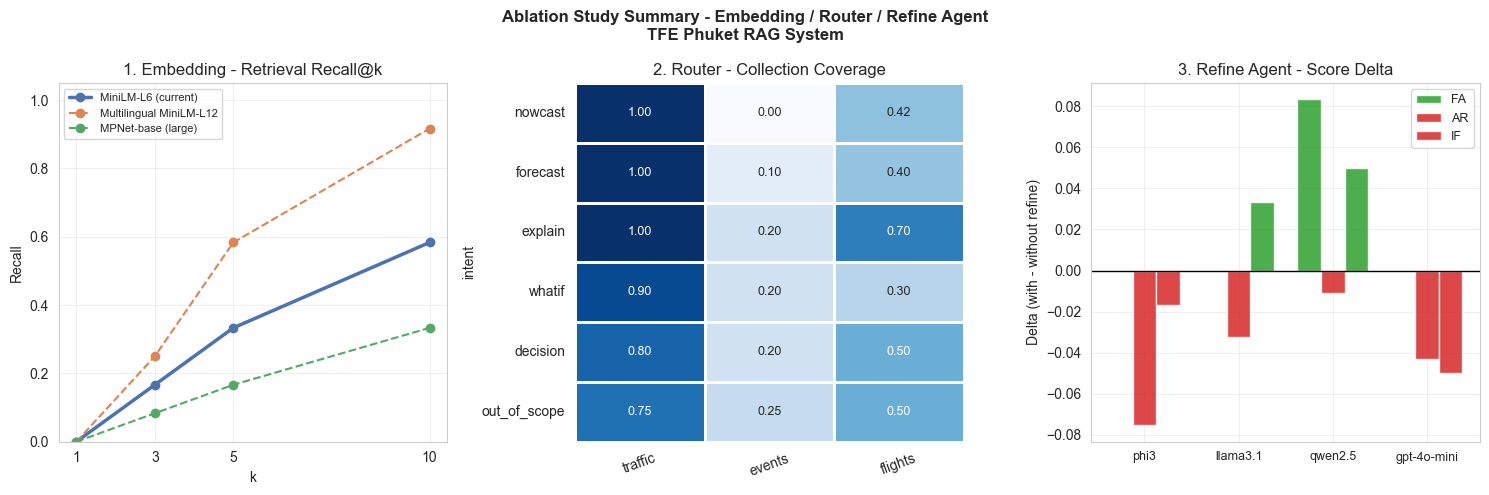

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Ablation Study Summary - Embedding / Router / Refine Agent\nTFE Phuket RAG System',
             fontsize=12, fontweight='bold')

# Panel 1: Recall@k curves
for i, m in enumerate(EMBED_MODELS):
    vals = [recall_results[m][k] for k in K_VALUES]
    lw = 2.5 if i == 0 else 1.5
    ls = '-' if i == 0 else '--'
    axes[0].plot(K_VALUES, vals, f'o{ls}', linewidth=lw, color=EMBED_COLORS[i],
                 label=EMBED_LABELS[m].replace('\n', ' '))
axes[0].set_title('1. Embedding - Retrieval Recall@k')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Recall')
axes[0].set_xticks(K_VALUES)
axes[0].set_ylim(0, 1.05)
axes[0].legend(fontsize=8)

# Panel 2: Router heatmap (compact)
hmap_small = heatmap_data[['traffic', 'events', 'flights']]
sns.heatmap(hmap_small, annot=True, fmt='.2f', cmap='Blues', vmin=0, vmax=1,
            ax=axes[1], linewidths=0.8, linecolor='white', cbar=False,
            annot_kws={'size': 9})
axes[1].set_title('2. Router - Collection Coverage')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=20)

# Panel 3: Refine delta bars
delta_data = {
    'FA': fa_comp.reindex(MODELS)['Delta'].fillna(0).values,
    'AR': ar_comp.reindex(MODELS)['Delta'].fillna(0).values,
    'IF': if_comp.reindex(MODELS)['Delta'].fillna(0).values,
}
x3 = np.arange(len(MODELS))
width3 = 0.25
for j, (metric, vals) in enumerate(delta_data.items()):
    offset = (j - 1) * width3
    bar_colors = ['#2ca02c' if v >= 0 else '#d62728' for v in vals]
    axes[2].bar(x3 + offset, vals, width3, label=metric, color=bar_colors,
                edgecolor='white', alpha=0.85)
axes[2].axhline(0, color='black', linewidth=1)
axes[2].set_xticks(x3)
axes[2].set_xticklabels([MODEL_LABELS[m] for m in MODELS], fontsize=9)
axes[2].set_title('3. Refine Agent - Score Delta')
axes[2].set_ylabel('Delta (with - without refine)')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'ablation_summary.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

In [16]:
# Export LaTeX table - embedding ablation
latex_embed = recall_df.to_latex(
    float_format='%.3f',
    caption='Embedding Model Ablation - Retrieval Recall@k on traffic\_monthly collection',
    label='tab:embedding_ablation',
    bold_rows=True,
)
with open(RESULTS_DIR / 'embedding_ablation_table.tex', 'w') as f:
    f.write(latex_embed)

# Export LaTeX table - refine impact
refine_summary = pd.DataFrame({
    'FA (no refine)':   fa_comp.reindex(MODELS)['Without refine'],
    'FA (refine)':      fa_comp.reindex(MODELS)['With refine'],
    'AR (no refine)':   ar_comp.reindex(MODELS)['Without refine'],
    'AR (refine)':      ar_comp.reindex(MODELS)['With refine'],
    'IF (no refine)':   if_comp.reindex(MODELS)['Without refine'],
    'IF (refine)':      if_comp.reindex(MODELS)['With refine'],
})
refine_summary.index = [MODEL_LABELS[m] for m in MODELS]
refine_summary.index.name = 'Model'
latex_refine = refine_summary.to_latex(
    float_format='%.3f',
    caption='Refine Agent Impact - FA / AR / IF without and with answer refinement',
    label='tab:refine_ablation',
    bold_rows=True,
)
with open(RESULTS_DIR / 'refine_ablation_table.tex', 'w') as f:
    f.write(latex_refine)

# Save summary CSV
recall_df.to_csv(RESULTS_DIR / 'embedding_recall.csv')
refine_summary.to_csv(RESULTS_DIR / 'refine_impact.csv')
routing_df.to_csv(RESULTS_DIR / 'routing_analysis.csv', index=False)

print('Exported:')
for f in sorted(RESULTS_DIR.iterdir()):
    print(f'  {f.name}')

Exported:
  ablation_summary.png
  embedding_ablation_table.tex
  embedding_recall.csv
  embedding_recall.png
  intent_fidelity_refine.csv
  refine_ablation_table.tex
  refine_by_intent.png
  refine_impact.csv
  refine_impact.png
  router_analysis.png
  routing_analysis.csv


<>:4: SyntaxWarning: "\_" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\_"? A raw string is also an option.
<>:4: SyntaxWarning: "\_" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\_"? A raw string is also an option.
/var/folders/mw/gfyxm3gj087g8k6n96l1g7mh0000gn/T/ipykernel_55436/4206192885.py:4: SyntaxWarning: "\_" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\_"? A raw string is also an option.
  caption='Embedding Model Ablation - Retrieval Recall@k on traffic\_monthly collection',
